# Environment Setup

In [1]:
# set up environment
# not required if using colab runtime - used for vscode jupyter notebooks
from pathlib import Path
from IPython.display import display

# only required if using colab runtime
# from os.path import path
# from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# only required if using colab runtime
# if not path.isdir('/content/drive'):
#     drive.mount('/content/drive')
# df = pd.read_csv("/content/drive/MyDrive/UA92/12 Applied Artificial Intelligence/Assignment dataset/adverts.csv")

csv_path = Path.cwd() / "adverts.csv"
df = pd.read_csv(csv_path)

In [2]:
# environment settings

# performance settings
render_plots = 1 # bool(0|1)
run_slow_models = 1 # bool(0|1)

# Initial data analysis

In [3]:
# initial dataset copy
df_initial = df.__deepcopy__() # type: ignore[reportCallIssue]

In [4]:
display(df_initial.head())

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [5]:
df_initial.info()

<class 'pandas.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  str    
 3   standard_colour        396627 non-null  str    
 4   standard_make          402005 non-null  str    
 5   standard_model         402005 non-null  str    
 6   vehicle_condition      402005 non-null  str    
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  str    
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  str    
dtypes: bool(1), float64(2), int64(2), str(7)
memory usage: 34.1 MB


In [6]:
df_initial.shape

(402005, 12)

In [7]:
display(df_initial.describe())

,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


In [8]:
df_missing_abs = df_initial.isna().sum()
df_missing_abs = df_missing_abs[df_missing_abs != 0]
df_missing_percentage = df_missing_abs / df_initial.count().max() * 100
df_missing = pd.DataFrame({
    'null/NaN count': df_missing_abs,
    'null/NaN %': df_missing_percentage
})
display(df_missing)

,null/NaN count,null/NaN %
mileage,127,0.031592
reg_code,31857,7.924528
standard_colour,5378,1.337794
year_of_registration,33311,8.286215
body_type,837,0.208206
fuel_type,601,0.149501


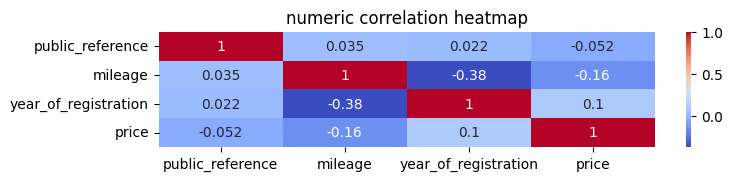

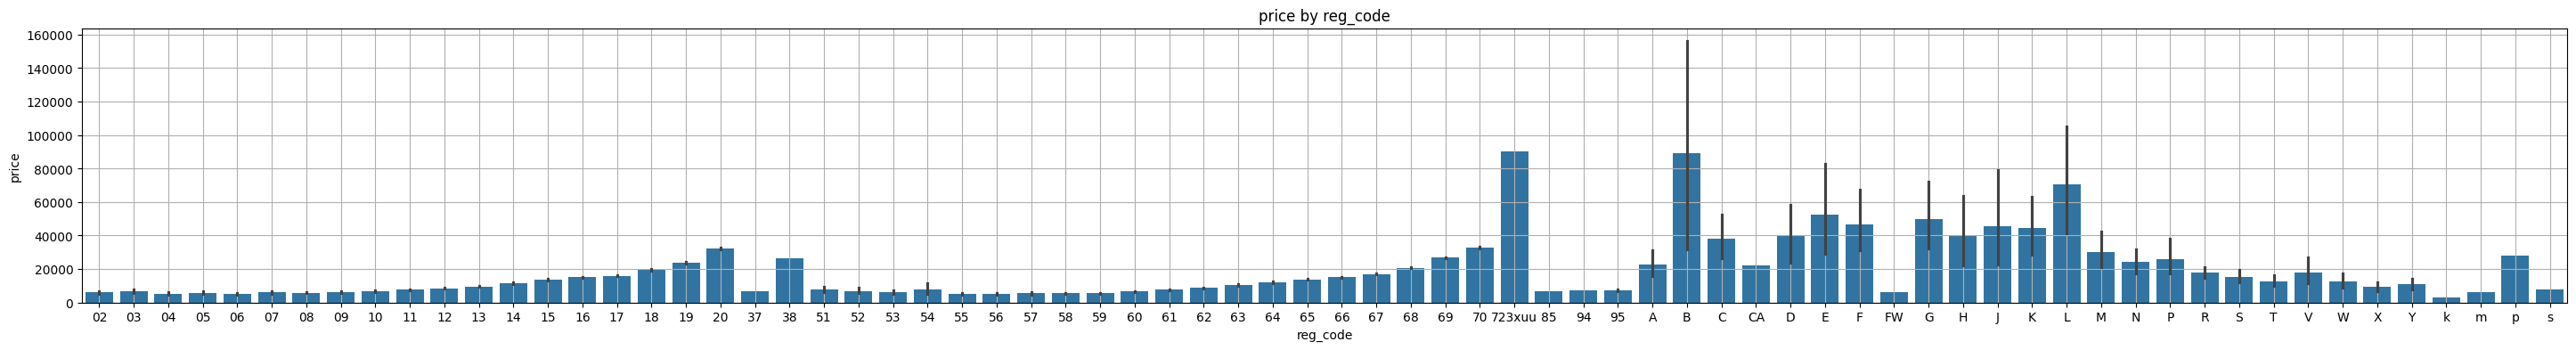

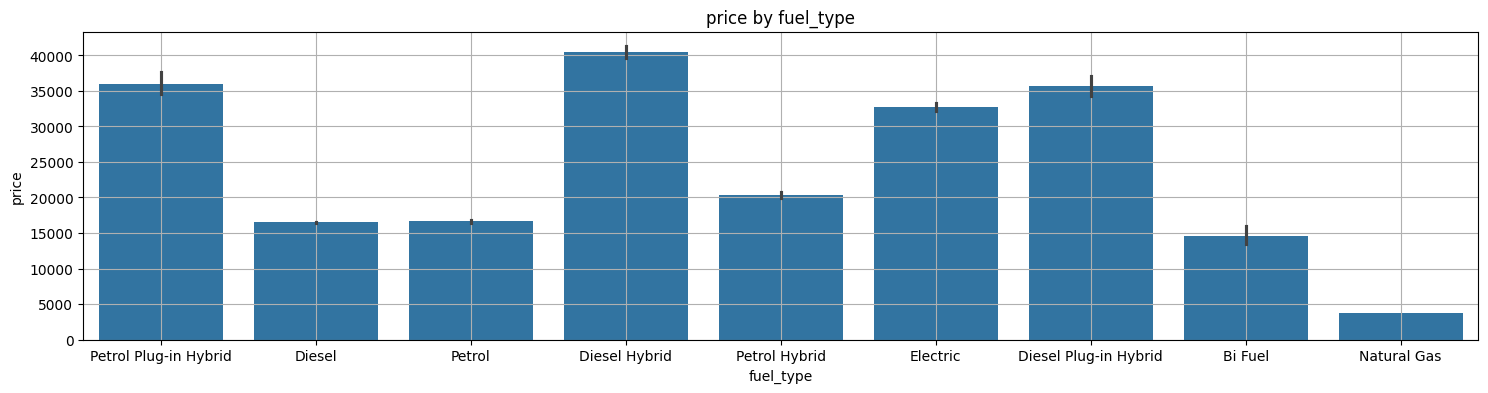

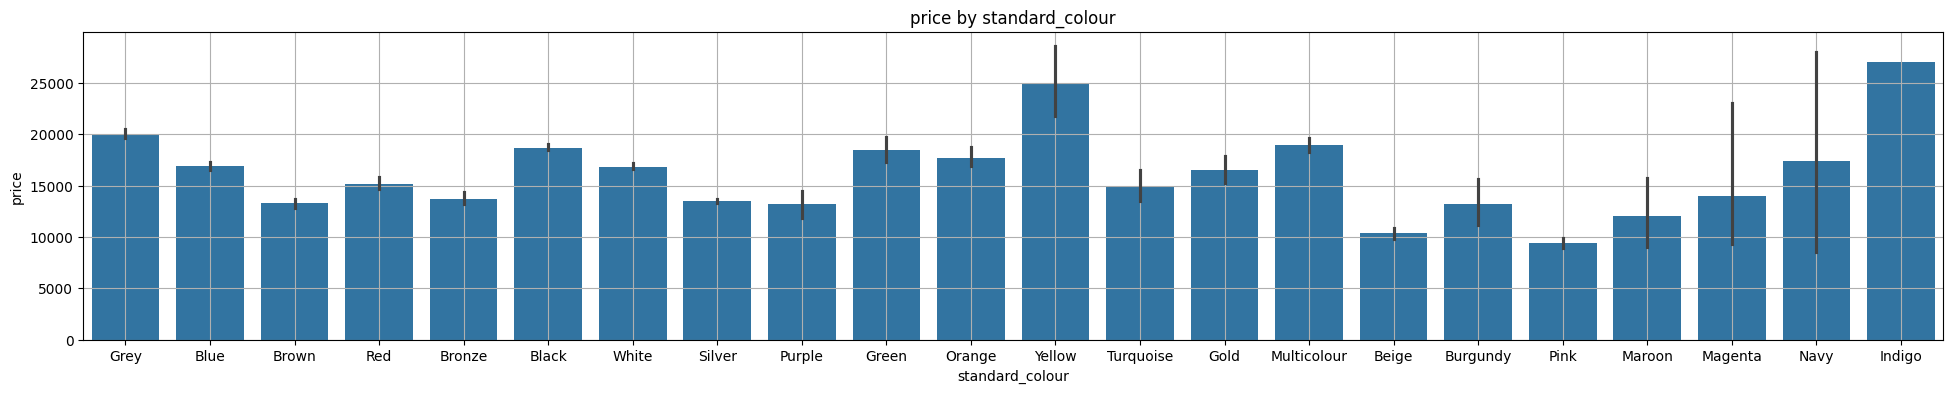

In [9]:
if render_plots:
    # correlation map
    plt.figure(figsize=(8, 1.5))
    plt.title('numeric correlation heatmap')
    sns.heatmap(
        data=df_initial.select_dtypes('number').corr(),
        cmap='coolwarm',
        annot=True
    )
    plt.show()

    plt.figure(figsize=(36,4))
    plt.title("price by reg_code")
    data = df_initial[['reg_code', 'price']].__deepcopy__()
    data['price'] = data['price'].astype(np.uint32)
    data['reg_code'] = data['reg_code'].astype('category').sort_values()
    sns.barplot(
        data=data,
        x='reg_code',
        y='price'
    )
    plt.grid()
    plt.show()

    plt.figure(figsize=(18,4))
    plt.title("price by fuel_type")
    sns.barplot(
        data=df_initial,
        x='fuel_type',
        y='price'
    )
    plt.grid()
    plt.show()

    plt.figure(figsize=(24,4))
    plt.title("price by standard_colour")
    sns.barplot(
        data=df_initial,
        x='standard_colour',
        y='price'
    )
    plt.grid()
    plt.show()

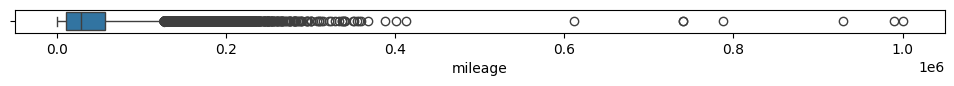

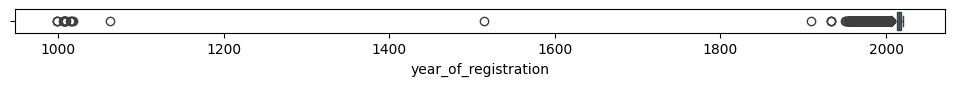

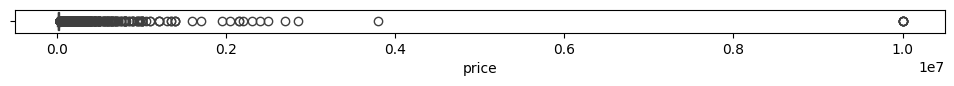

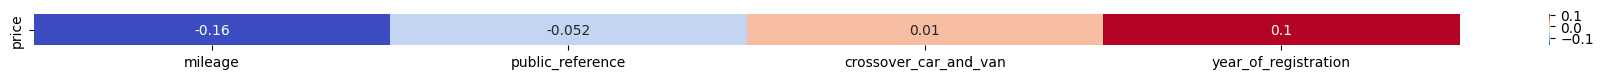

In [10]:
if render_plots:
    for subset in df_initial[['mileage', 'year_of_registration', 'price']]:
        plt.figure(figsize=(12,0.3))
        sns.boxplot(
            data=df_initial,
            x=subset
        )
        plt.show()

    corr = df_initial.corr(numeric_only=True)["price"].drop("price").sort_values() # ChatGPT
    corr = corr.to_frame().T # ChatGPT
    plt.figure(figsize=(23, 0.4))
    sns.heatmap(
        data=corr,
        annot=True,
        cmap='coolwarm'
    )
    plt.show()

In [11]:
columns = df_initial[['mileage', 'year_of_registration', 'price']].columns
distributions = pd.DataFrame(index=['mean', 'median', 'mode', 'std', 'skew'], columns=columns)

# Gemini
for col in columns:
    distributions.loc['mean', col] = df_initial[col].mean()
    distributions.loc['median', col] = df_initial[col].median()

    mode_val = df_initial[col].mode()
    distributions.loc['mode', col] = mode_val.iloc[0]

    distributions.loc['std', col] = df_initial[col].std()
    distributions.loc['skew', col] = df_initial[col].skew()

display(distributions)

,mileage,year_of_registration,price
mean,37743.595656,2015.006206,17341.965799
median,28629.5,2016.0,12600.0
mode,0.0,2017.0,8995
std,34831.724018,7.962667,46437.460951
skew,1.451132,-87.909954,154.681527


## Description
- Semantics
    - `public_reference` likely refers to some kind of reference number.
    - `mileage` refers to a vehicle's odometer reading.
    - `reg_code` could be associated with a vehicle's registration number (number plate).
    - `standard_colour`, `standard_make`, `standard_model` refer to the colour, manufacturer, and model of a vehicle.
    - `vehicle_condition` refers to the cosmetic and working conditions of a vehicle.
    - `year_of_registration` refers to the year on which a car was registered with a vehicle licensing authority.
    - `price` refers to the market or retail price of a vehicle.
    - `body_type` refers to the type/category of a vehicle.
    - `crossover_car_and_van` may refer to a vehicle being categorised as a mix between a car and van.
    - `fuel_type` refers to what kind of fuel a vehicle takes.
- Observed Data Types
    - 7 columns in the initial dataset are of type 'object' (`np.dtypes.ObjectDType`), which is indescriptive, and should be converted where possible.
    - `public_reference: int` - integer type implies quantitative data
    - `mileage: float | NaN` - quantitative
    - `reg_code: str | float | NaN` - qualitative
    - `standard_colour, standard_make, standard_model: str` - qualitative
    - `vehicle_condition: str = "NEW" | "USED"` binary classification, could be converted to bool - qualitative
    - `year_of_registration: float | NaN` - quantitative
    - `price: int` - quantitative
    - `body_type: str | NaN` - qualitative
    - `crossover_car_and_van: bool` - qualitative
    - `fuel_type: str | NaN` - qualitative
- Corrections
    - `vehicle_condition` refers to whether a vehicle is used or not.
    - `public_reference` doesn't seem to hold any significance as quantitative data, thus should be qualitative.
- Predictors (From most to least confident)
    - `standard_model` - certain vehicle models should be worth more.
    - `mileage` should be inversely proportional to price.
    - `vehicle_condition` - on average, a new car should be more expensive than a used one.
    - `standard_make` - some manufacturers make more expensive vehicles.
    - `year_of_registration` should be proportional to price, with some caveats ("classic" cars will be more valuable and likely appreciate in value over time).
    - some `body_type`s may be worth more than others.
    - vehicles with some `fuel_type`s may be worth more than others.
- Numerical analysis
    - There are many outliers in the numerical columns of the dataset, most notably in the `year_of_registration` column, with a minimum value of 999, indicating data error (The first automobile was created in 1885), and many modern cars in the 0.1 percentile (1983) or lower. This dataset doesn't seem to include vehicles created before the 21st century or late 20th century.
    - The dataset doesn't have any information on what units each value was measured in, going forward, we'll assume miles for `mileage` and GBP for `price`.
    - The `mileage` maximum value of 999,999 could represent a maximum 6-digit odometer reading, and the true mileage could be higher.
    - There are vehicles with:
        - `(vehicle_condition = "USED") && (mileage == 0)` indicating an odometer overflow or data error.
        - `(vehicle_condition = "NEW") && (0 < mileage <= 100)`.
        - `(vehicle_condition = "USED") && (0 < mileage <= 100)`.
        - We can assume that retailers will have a margin of acceptance for a "new" car, and `mileage` <= 100 miles seems like an appropriate margin. If this margin rule is applied to all the data, then `vehicle_condition` becomes redundant. Otherwise, depending on specific business rules on how a car is categorised as new or used, the data will contain inconsistencies.
- Importance
    - `public_reference` is likely unimportant, so it will be dropped.
    - due to reasons mentioned beforehand, `vehicle_condition` will be dropped.
    - `mileage` and `year_of_registration` will be key predictors of price.
    - The `standard_model` of a vehicle will likely be strongly linked to it's price.

# Data handling

## Reworking columns

In [12]:
# data cleanup
if 'public_reference' in df.columns:
    df = df.drop('public_reference', axis=1) # The public_reference column is meaningless

# There are inconsistencies with how this data labels vehicle_condition and mileage,
# so we'll drop the column.
df = df[~((df['mileage'] == 0) & (df['vehicle_condition'] == "USED"))]
if 'vehicle_condition' in df.columns:
    df = df.drop('vehicle_condition', axis=1)

## Removing missing data

In [13]:
# missing data handling
for subset in ['mileage', 'reg_code', 'standard_colour', 'body_type', 'fuel_type']:
    df = df.dropna(subset=subset)
df['year_of_registration'] = df['year_of_registration'].fillna(df['year_of_registration'].median())

## Memory optimisation

In [14]:
# data type memory optimisation
print(f"memory usage before optimisation: {(df.memory_usage().sum() / 1024 ** 2).round(2):,} MB")
df['reg_code'] = df['reg_code'].astype('category')
df['mileage'] = df['mileage'].astype(np.uint32)
df['standard_colour'] = df['standard_colour'].astype('category')
df['standard_make'] = df['standard_make'].astype('category')
df['standard_model'] = df['standard_model'].astype('category')
df['year_of_registration'] = df['year_of_registration'].astype(np.uint16)
df['price'] = df['price'].astype(np.uint32)
df['body_type'] = df['body_type'].astype('category')
df['fuel_type'] = df['fuel_type'].astype('category')
print(f"memory usage after optimisation: {(df.memory_usage().sum() / 1024 ** 2).round(2):,} MB")

memory usage before optimisation: 28.15 MB
memory usage after optimisation: 9.05 MB


In [15]:
# convert year_of_registration into vehicle_age to reduce domain and memory usage by converting to uint8
from datetime import datetime

if 'year_of_registration' in df.columns:
    df['year_of_registration'] = datetime.now().year - df['year_of_registration']
    df.rename(inplace=True, columns={'year_of_registration': 'vehicle_age'})

    df['vehicle_age'] = df['vehicle_age'].astype(np.uint8)

## Removing outliers & errors

In [16]:
# remove outliers
for subset in df.select_dtypes('number'):
    iqr = df[subset].quantile(0.75) - df[subset].quantile(0.25)
    min_value = df[subset].quantile(0.25) - 1.5 * iqr
    max_value = df[subset].quantile(0.75) + 1.5 * iqr
    df = df[(df[subset] > min_value) & (df[subset] < max_value)]

df['reg_code'] = df['reg_code'].astype('string').astype('category') # remove empty reg_code categories
# remove erroneous values (data error, odometer overflow, etc.)
if 'used_vehicle' in df.columns:
    df = df[~((df['mileage'] == 0) & (df['used_vehicle'] == True))]

In [17]:
df_pre_encode = df.__deepcopy__()

## Encoding data

In [18]:
# pyright: reportAttributeAccessIssue=false
# pyright: reportUnboundVariable=false

# encode data using target encoding
for subset in ['reg_code', 'standard_colour', 'standard_make', 'standard_model', 'body_type', 'fuel_type']:
    means = df.groupby(subset, observed=False)["price"].mean()
    df[str(subset + "_te")] = df[subset].map(means).astype(np.uint16) # high precision not required (has negligible effect on models), so using uint16 instead of float64
    df = df.drop(subset, axis=1)

## Plots

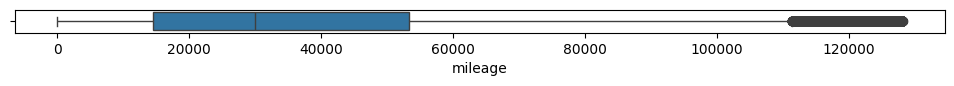

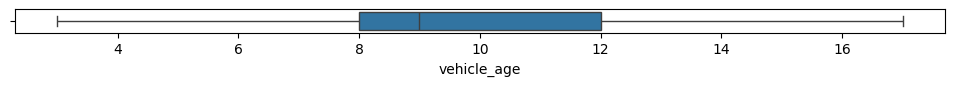

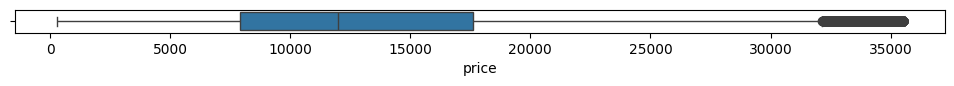

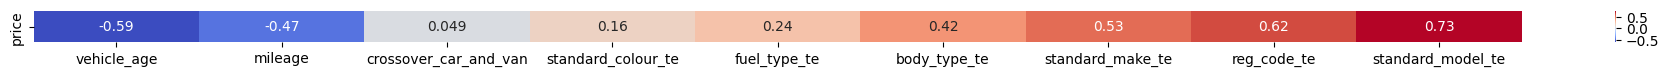

In [19]:
if render_plots:
    for subset in df[['mileage', 'vehicle_age', 'price']]:
        plt.figure(figsize=(12,0.3))
        sns.boxplot(
            data=df,
            x=subset
        )
        plt.show()

    corr = df.corr(numeric_only=True)["price"].drop("price").sort_values() # ChatGPT
    corr = corr.to_frame().T # ChatGPT
    plt.figure(figsize=(24, 0.4))
    sns.heatmap(
        data=corr,
        annot=True,
        cmap='coolwarm'
    )
    plt.show()

In [20]:
columns = df[['mileage', 'vehicle_age', 'price']].columns
distributions = pd.DataFrame(index=['mean', 'median', 'mode', 'std', 'skew'], columns=columns)

# Gemini
for col in columns:
    distributions.loc['mean', col] = df[col].mean()
    distributions.loc['median', col] = df[col].median()

    mode_val = df[col].mode()
    distributions.loc['mode', col] = mode_val.iloc[0]

    distributions.loc['std', col] = df[col].std()
    distributions.loc['skew', col] = df[col].skew()

display(distributions)

,mileage,vehicle_age,price
mean,36747.127434,10.108088,13380.642724
median,30000.0,9.0,11995.0
mode,10,9,8995
std,28155.1515,2.778161,7338.409455
skew,0.894103,0.676921,0.808984


In [21]:
display(df.describe())

,mileage,vehicle_age,price,reg_code_te,standard_colour_te,standard_make_te,standard_model_te,body_type_te,fuel_type_te
count,311580.000000,311580.000000,311580.000000,311580.000000,311580.000000,311580.000000,311580.000000,311580.000000,311580.00000
mean,36747.127434,10.108088,13380.642724,13380.107507,13380.073461,13380.231241,13380.140105,13380.233645,13380.10795
std,28155.151500,2.778161,7338.409455,4526.372877,1167.738055,3912.526724,5391.075341,3079.582735,1793.66670
min,1.000000,3.000000,295.000000,3995.000000,7001.000000,1518.000000,675.000000,10222.000000,11976.00000
25%,14565.750000,8.000000,7891.000000,10368.000000,11980.000000,10983.000000,8795.000000,10222.000000,11976.00000
50%,30000.000000,9.000000,11995.000000,13607.000000,13522.000000,12687.000000,12767.000000,14628.000000,11976.00000
75%,53262.000000,12.000000,17599.250000,15589.000000,14118.000000,17243.000000,17015.000000,16748.000000,14450.00000
max,128100.000000,17.000000,35500.000000,27500.000000,27000.000000,33541.000000,34995.000000,24783.000000,28229.00000


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 311580 entries, 1 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   mileage                311580 non-null  uint32
 1   vehicle_age            311580 non-null  uint8 
 2   price                  311580 non-null  uint32
 3   crossover_car_and_van  311580 non-null  bool  
 4   reg_code_te            311580 non-null  uint16
 5   standard_colour_te     311580 non-null  uint16
 6   standard_make_te       311580 non-null  uint16
 7   standard_model_te      311580 non-null  uint16
 8   body_type_te           311580 non-null  uint16
 9   fuel_type_te           311580 non-null  uint16
dtypes: bool(1), uint16(6), uint32(2), uint8(1)
memory usage: 8.9 MB


In [23]:
display(df.sample(5))

,mileage,vehicle_age,price,crossover_car_and_van,reg_code_te,standard_colour_te,standard_make_te,standard_model_te,body_type_te,fuel_type_te
398762,20000,10,17295,False,13607,14892,16395,13988,10222,11976
372975,8500,7,31291,False,18167,13460,16395,22346,10222,11976
289102,3268,7,22980,False,18167,13522,17243,16394,11497,14450
25846,68000,10,9995,False,13607,13522,11506,10553,10222,17229
88027,25019,14,5480,False,7558,10140,12367,6927,10222,11976


# Machine learning

## Model Setup

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE_SEED = 47

In [25]:
y = df['price']
y_train, y_test = train_test_split(
    y,
    test_size=0.3,
    random_state=RANDOM_STATE_SEED
)

scaler = StandardScaler()
# scaler = MinMaxScaler()

In [26]:
# pyright: reportUndefinedVariable=false
metrics = {}
def log_metrics(y_pred, name: str) -> None:
    metrics[name] = {
        'r²': f'{r2_score(y_test, y_pred):.4f}',
        'mae': f'{mean_absolute_error(y_test, y_pred):.4f}',
        'mse': f'{mean_squared_error(y_test, y_pred):.4f}',
        'rmse': f'{root_mean_squared_error(y_test, y_pred):.4f}'
    }

In [27]:
# pyright: reportUndefinedVariable=false
def show_comparison() -> None:
    if render_plots:
        fig, axes = plt.subplots(
            1, 2,
            figsize=(16, 4)
        )

        sns.histplot(
            data=y_test,
            kde=True,
            ax=axes[0]
        )
        axes[0].set_title('expected prices')

        sns.histplot(
            data=y_pred,
            kde=True,
            ax=axes[1]
        )
        axes[1].set_title('predicted prices')
        axes[1].set(xlabel='price')
        plt.show()

        plt.subplots(figsize=(16, 4))
        sns.kdeplot(
            data=y_test,
            color='crimson',
            label='test data',
            fill=True
        )
        sns.kdeplot(
            data=y_pred,
            color='limegreen',
            label='predicted',
            fill=True
        )
        plt.legend()
        plt.show()

In [28]:
# pyright: reportUndefinedVariable=false
def generate_test_split() -> None:
    """Assigns train_test_split values to global variables (X_train, X_test),
    using global variable X and pre-set parameters for train_test_split
    """
    global X_train, X_test
    X_train, X_test = train_test_split(
        X,
        test_size=0.3,
        random_state=RANDOM_STATE_SEED
    )
def generate_scaled_features() -> None:
    """Assigns scaler.fit_transform values to global variables (X_train_scaled, X_test_scaled)
    using global variables (X_train, X_test)
    """
    global X_train_scaled, X_test_scaled
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

## Model 1 (Linear Regressor)

In [ ]:
def run_linear_regressor(*, exclude_columns: list[str] = [], return_model: bool = False, show_plots: bool = False) -> tuple[np.ndarray, LinearRegression] | np.ndarray:
    global X
    X = df.drop(columns=['price', *exclude_columns])

    generate_test_split()
    generate_scaled_features()

    X_train, X_test = X_train_scaled, X_test_scaled

    model = LinearRegression()
    model.fit(X_train, y_train)
    global y_pred
    y_pred = model.predict(X_test)

    df_coef = pd.DataFrame({
        'feature': X.columns,
        'coefficient': model.coef_
    })
    display(df_coef)

    if show_plots:
        show_comparison()

    if not return_model:
        return y_pred
    else:
        return y_pred, model

# log_metrics(
#     run_linear_regressor(
#         exclude_columns=['mileage'],
#     ),
#     name="Linear Regressor no_mileage_test"
# )

### Full feature set

,feature,coefficient
0,mileage,-1671.086613
1,vehicle_age,735.735374
2,crossover_car_and_van,114.892753
3,reg_code_te,3347.952020
4,standard_colour_te,159.657588
5,standard_make_te,1278.844078
6,standard_model_te,3614.576097
7,body_type_te,367.202475
8,fuel_type_te,397.597372


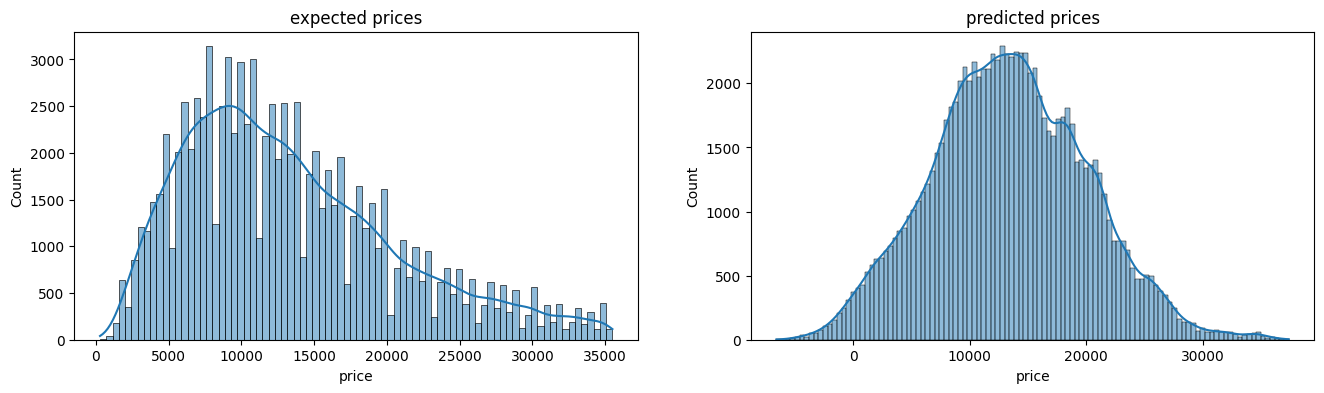

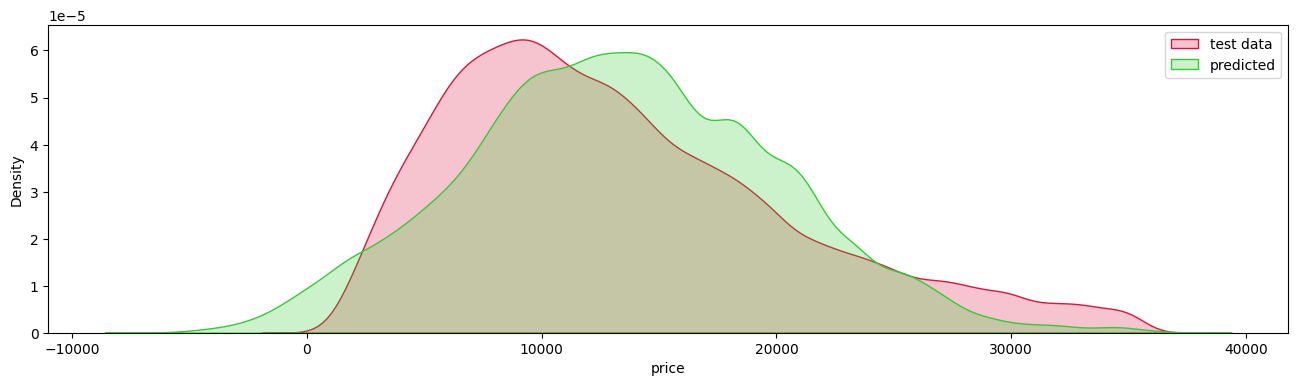

In [ ]:
y_pred, lr_model = run_linear_regressor(return_model=True, show_plots=True)

log_metrics(
    y_pred,
    name="Linear Regressor full"
)

As expected, the coefficient results show that as `mileage` goes up, price goes down, but as `vehicle_age` goes up, price also goes up, which contradicts the original hypothesis. The following cell attempts to investigate the correlation between `vehicle_age` and `price` at A. different intervals of `mileage`, and B. different values of mileage. Findings show that the correlation should be negative for most mileage subsets of the data, as originally hypothesised.

This suggests multicollinearity between `mileage` and `vehicle_age`, or other features.

np.float64(-0.45177276971976704)

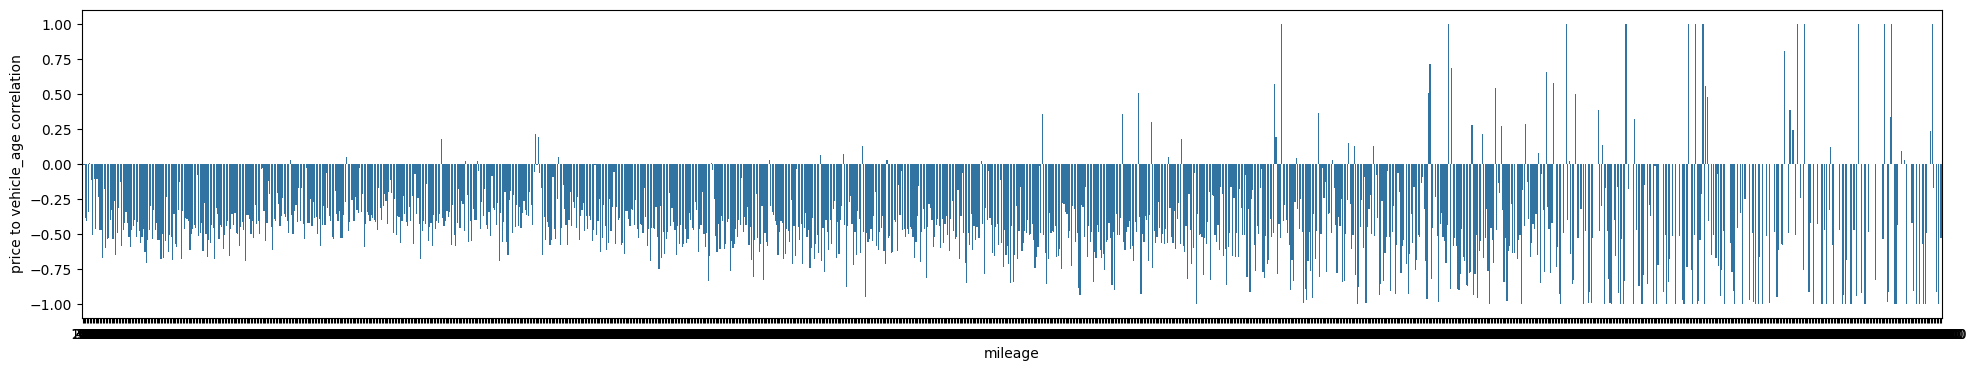

np.float64(-0.45283934900264966)

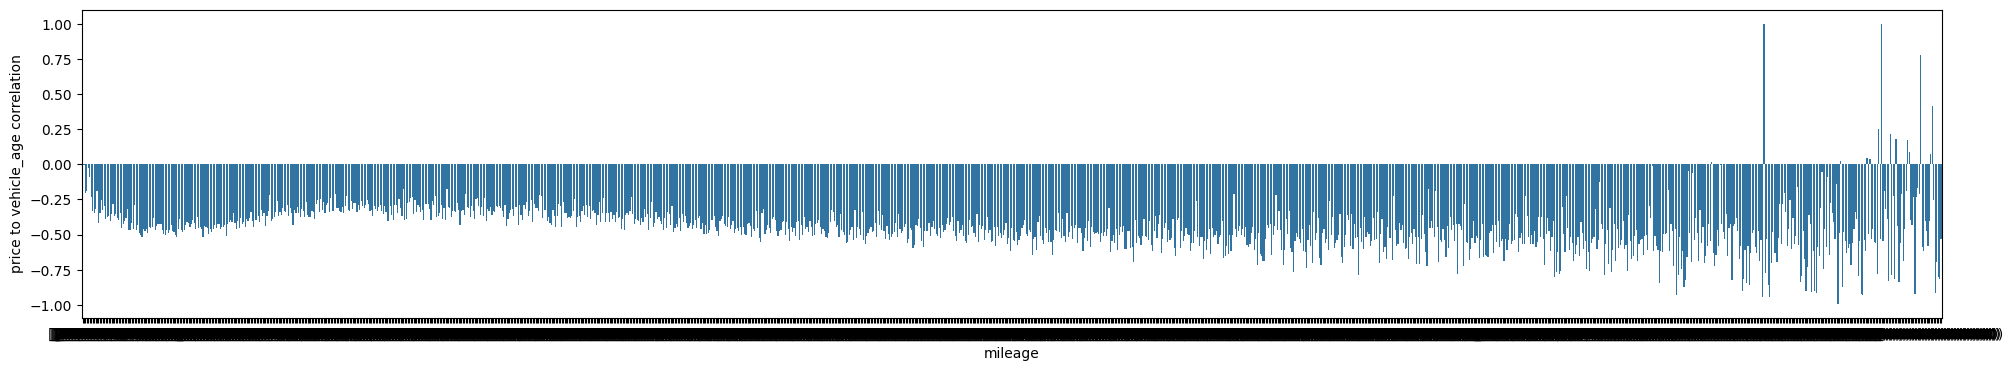

In [31]:
def generate_vehicle_age_price_corr_report(range_params: tuple[int,int,int], *, show_ranges: bool) -> None:
    """generate a vehicle_age to price correlation report for specific mileage values

    Parameters:
    range_params -- parameters to be passed into the range(start, end, increment) of a for loop, the range of values chosen for mileage
    Keyword Parameters:
    show_ranges -- if True, generate report using mileage intervals instead of single values.
    """

    if render_plots:
        increment = range_params[2]
        data = df[['price', 'vehicle_age']].corr().iloc[0].iloc[[1]]

        for n in range(*range_params):
            if show_ranges:
                index = f'[{n}..{n+increment})'
                cur_mileage = df[(n <= df['mileage']) & (df['mileage'] < n+increment)]
            else:
                index = f'{n}'
                cur_mileage = df[df['mileage'] == n]
            data.loc[index] = cur_mileage[['price', 'vehicle_age']].corr().iloc[0].iloc[[1]].vehicle_age

        data = data.drop(index='vehicle_age')
        data.rename('price to vehicle_age correlation', inplace=True)
        display(data.mean())

        ax = plt.figure(figsize=(24,4))
        sns.barplot(
            data=data
        )
        plt.xlabel('mileage')
        plt.show()

generate_vehicle_age_price_corr_report((0, df['mileage'].max(), 100), show_ranges=False)
generate_vehicle_age_price_corr_report((0, df['mileage'].max(), 100), show_ranges=True)

### Exclude features

,feature,coefficient
0,vehicle_age,119.174214
1,crossover_car_and_van,94.777742
2,reg_code_te,4015.504498
3,standard_colour_te,109.320960
4,standard_make_te,1215.138685
5,standard_model_te,3585.676190
6,body_type_te,306.680889
7,fuel_type_te,180.666856


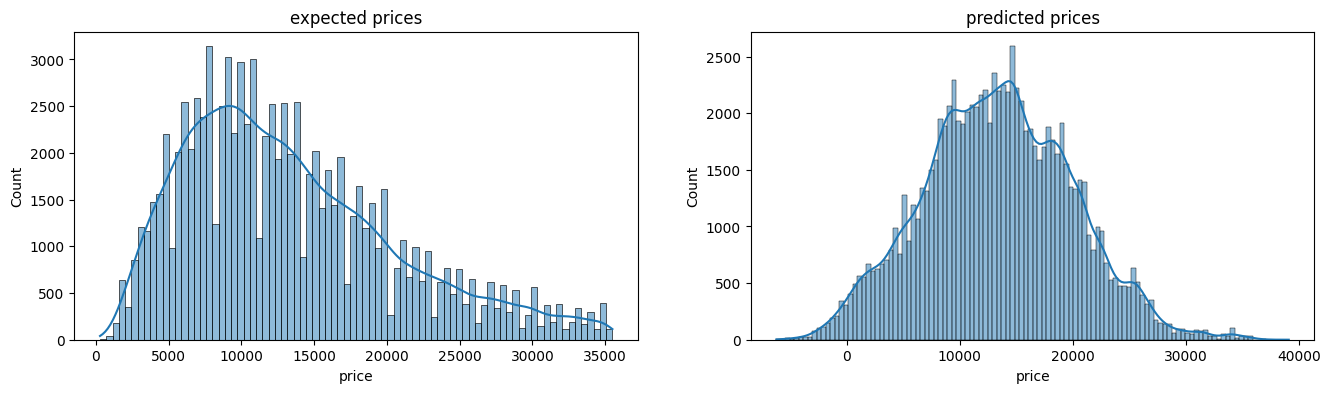

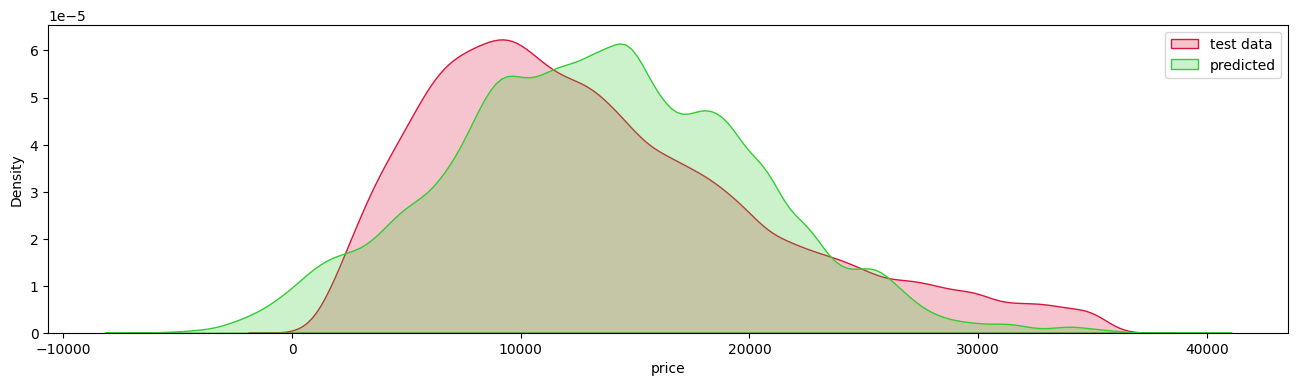

In [32]:
log_metrics(run_linear_regressor(
    exclude_columns=['mileage']
), "Linear Regressor -mileage")

The previous cell demonstrates that it's not only `vehicle_age` and `mileage` which are collinear, and that `vehicle_age` or `mileage` may still be implicitly related with other features.
The following cells will test this theory by removing `standard_model` and `reg_code` features (`reg_code` and `standard_model` imply `vehicle_age`)

,feature,coefficient
0,vehicle_age,-4289.516794
1,crossover_car_and_van,229.252123
2,standard_colour_te,210.641903
3,standard_make_te,3293.771481
4,body_type_te,1513.362888
5,fuel_type_te,524.375292


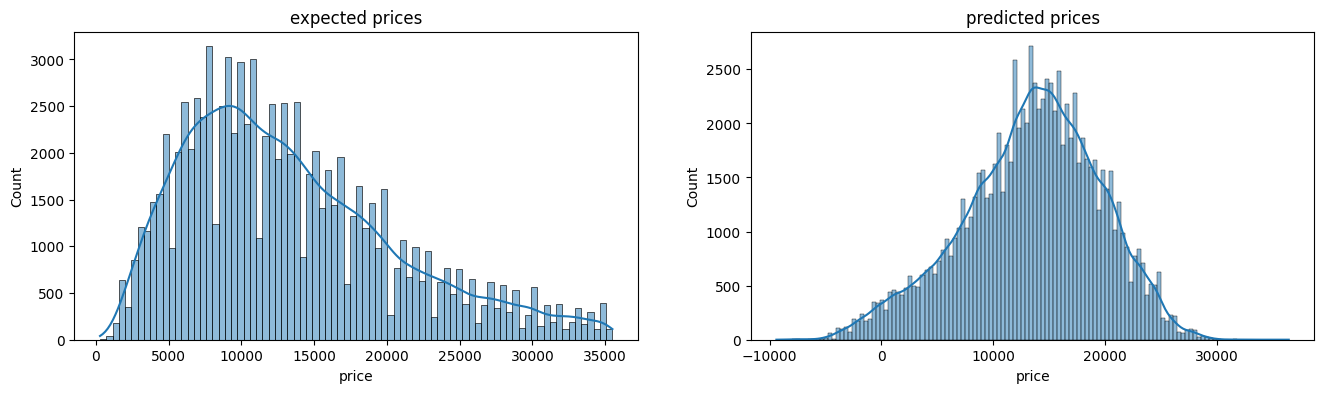

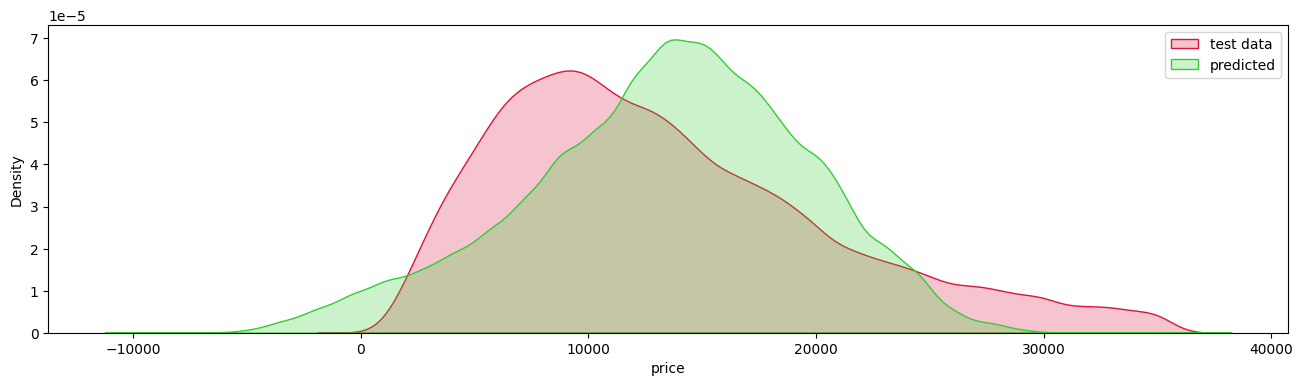

In [33]:
log_metrics(run_linear_regressor(
    exclude_columns=['mileage', 'standard_model_te', 'reg_code_te']
), "Linear Regressor -mileage,model,reg")

,feature,coefficient
0,vehicle_age,-3724.360738
1,crossover_car_and_van,84.749258
2,standard_colour_te,126.892934
3,standard_make_te,1127.163483
4,standard_model_te,3712.589698
5,body_type_te,289.280805
6,fuel_type_te,143.216414


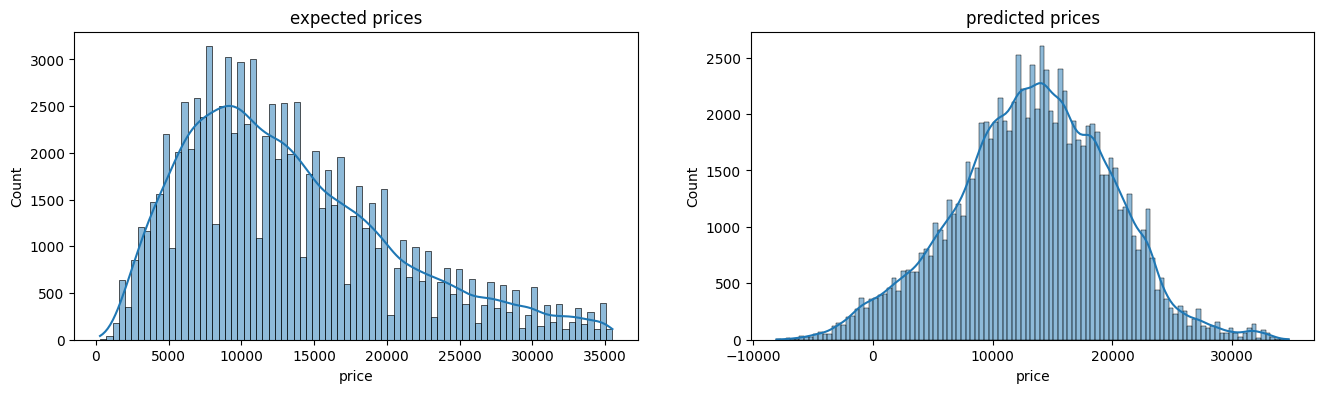

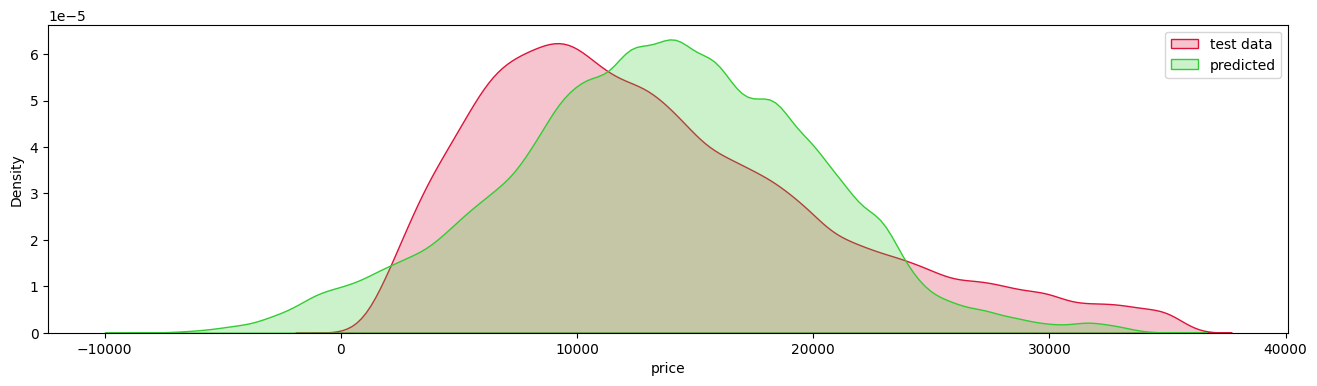

In [34]:
log_metrics(run_linear_regressor(
    exclude_columns=['mileage', 'reg_code_te']
), "Linear Regressor -mileage,reg" )

,feature,coefficient
0,mileage,-4088.037262
1,crossover_car_and_van,276.454173
2,standard_colour_te,416.854774
3,standard_make_te,3435.003188
4,body_type_te,1775.611613
5,fuel_type_te,1066.742012


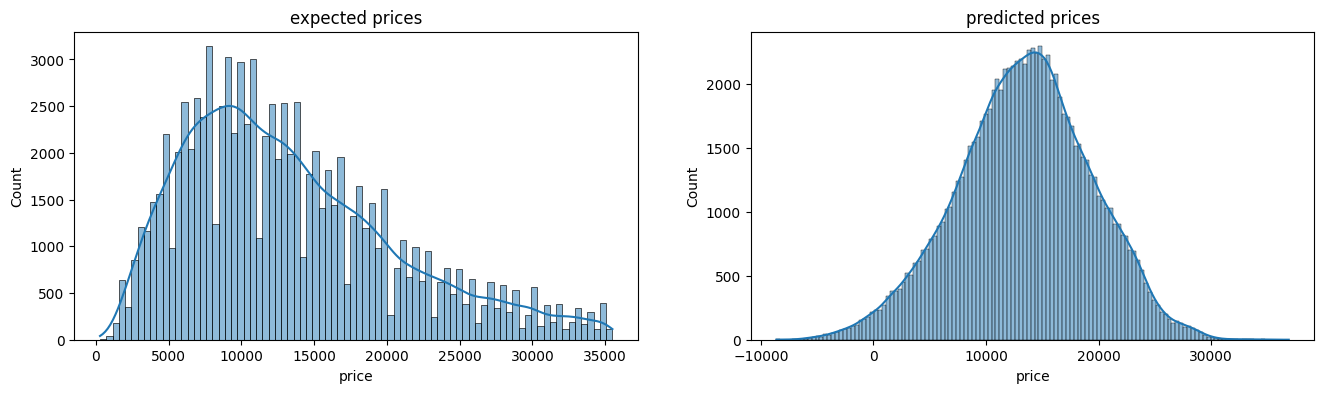

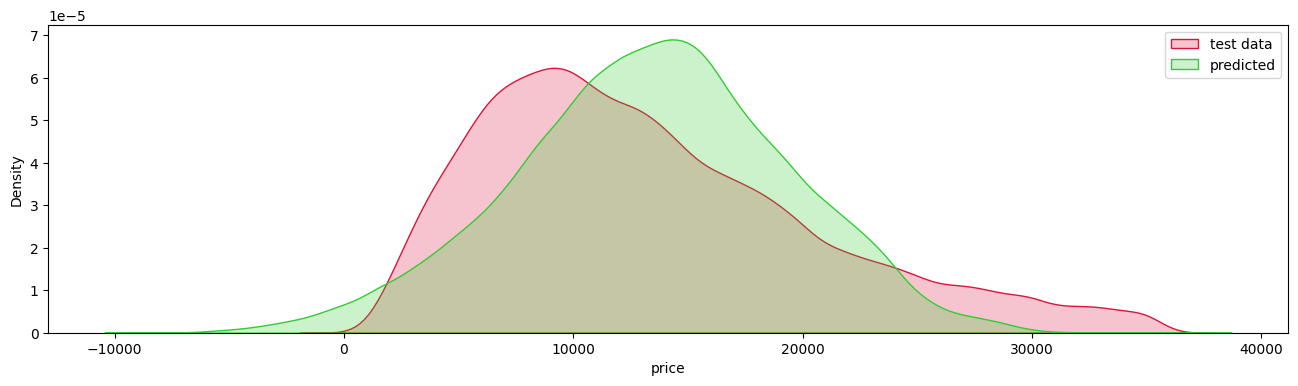

In [35]:
log_metrics(run_linear_regressor(
    exclude_columns=['vehicle_age', 'standard_model_te', 'reg_code_te']
), "Linear Regressor -age,model,reg")

,feature,coefficient
0,mileage,-3608.938011
1,crossover_car_and_van,109.405143
2,standard_colour_te,288.952807
3,standard_make_te,992.328572
4,standard_model_te,4168.668491
5,body_type_te,359.531539
6,fuel_type_te,575.791069


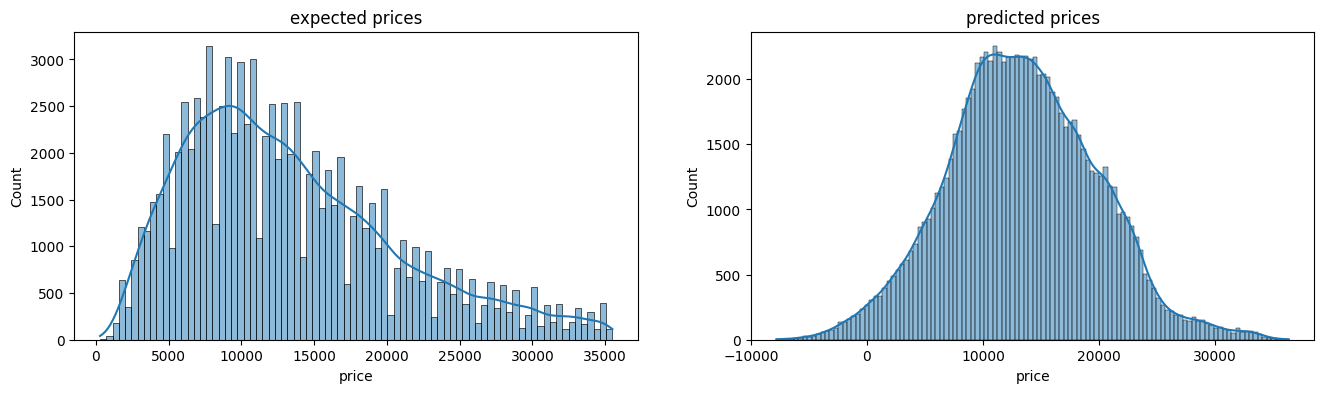

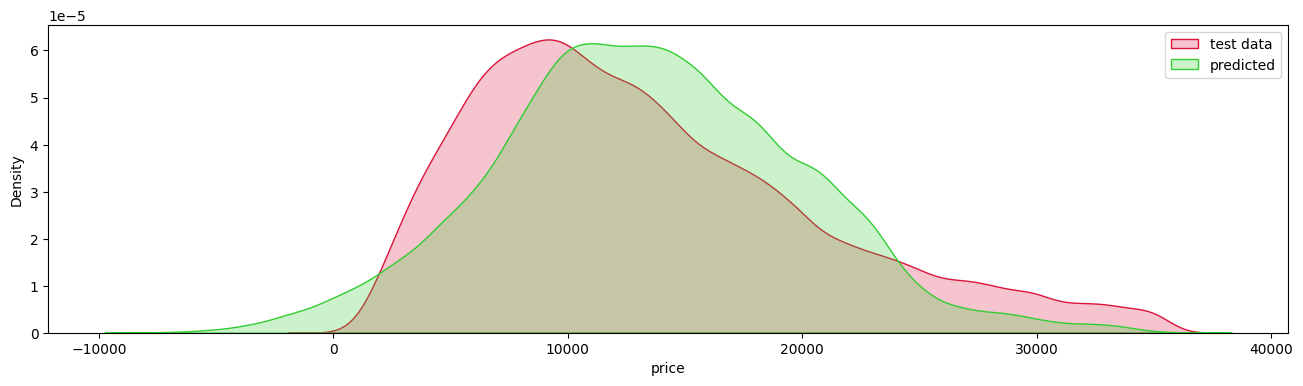

In [36]:
log_metrics(run_linear_regressor(
    exclude_columns=['vehicle_age', 'reg_code_te']
), "Linear Regressor -age,reg")

As expected, removing features `reg_code` and `standard_model` caused the `vehicle_age` coefficient to become negative. This suggests that the `reg_code` and `standard_model` features are more important than `mileage` and `vehicle_age`.

It is important to note that the removal of these features causes the r² score for those model variants to drop significantly, and so these models should not be used for predicting vehicle price, but instead as a demonstration of multicollinearity in the features of the dataset, and the effects on the model coefficients of removing these features.

,feature,coefficient
0,mileage,-465.391071
1,vehicle_age,-4022.562107


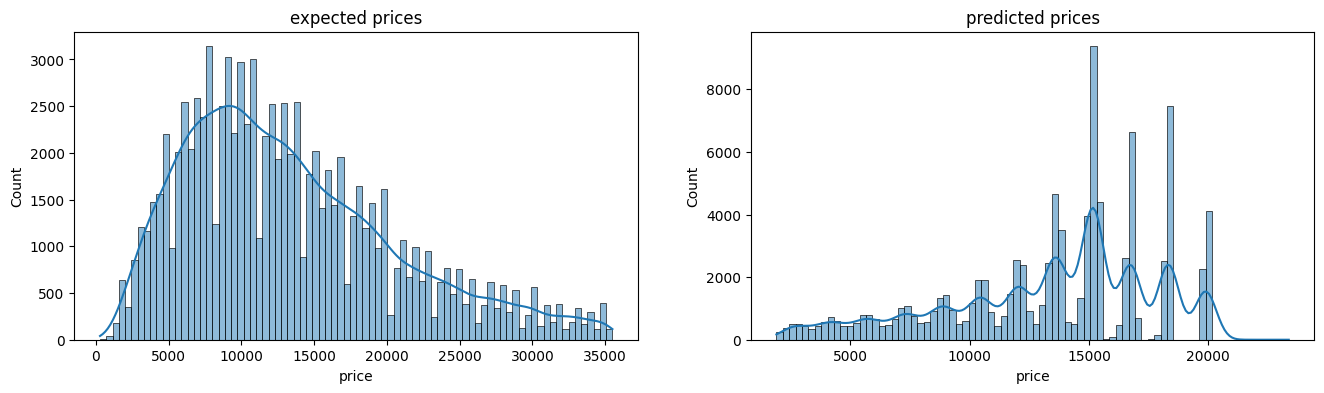

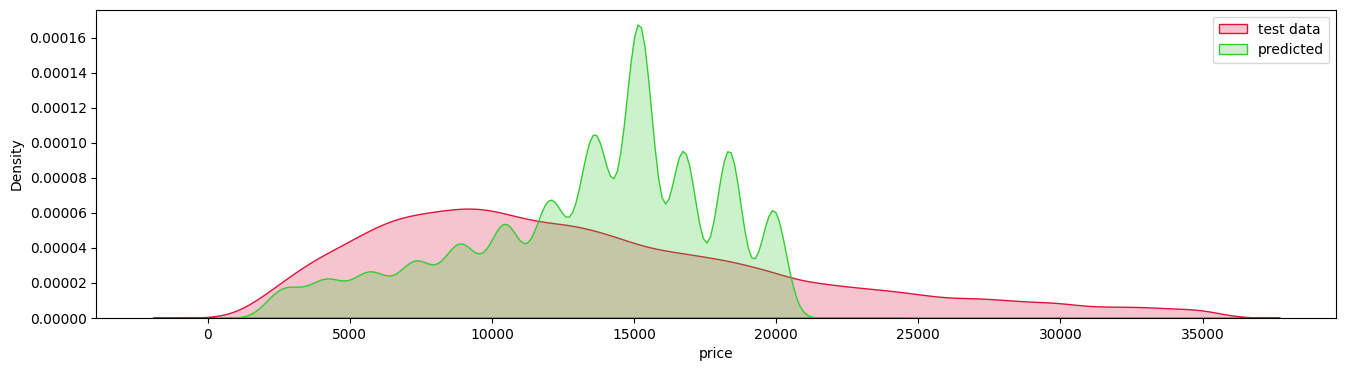

In [37]:
log_metrics(run_linear_regressor(
    exclude_columns=['standard_model_te', 'reg_code_te', 'standard_make_te', 'standard_colour_te', 'crossover_car_and_van', 'fuel_type_te', 'body_type_te']
), "Linear Regressor +age,mileage")

The previous cell demonstrates that when all other features are removed, both `mileage` and `vehicle_age` have a negative coefficient, but doesn't address the fact that they are probably collinear with eachother.

## Model 2 (Decision Tree Regressor)

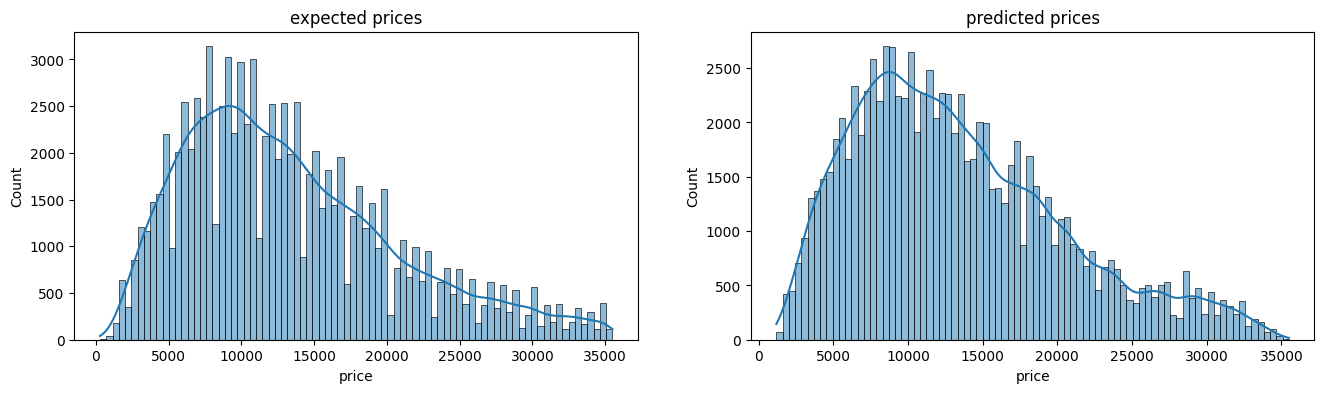

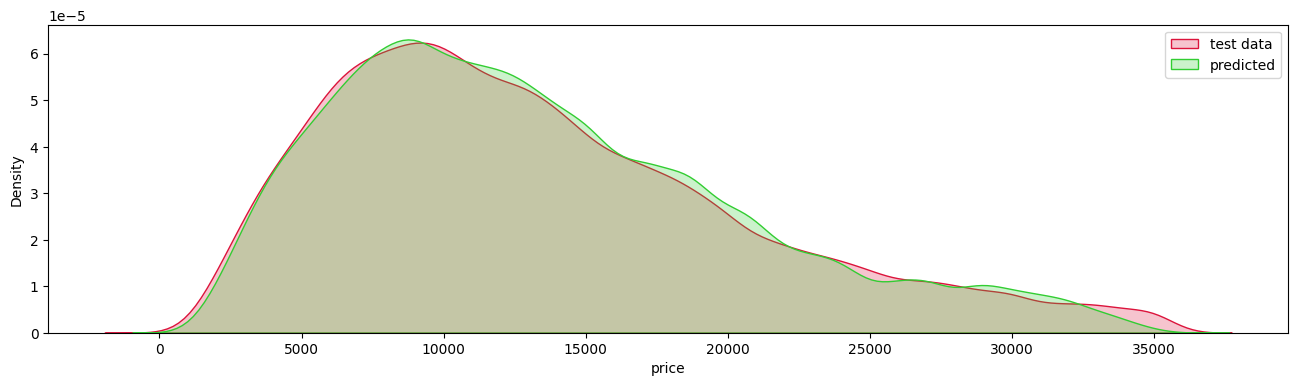

In [38]:
X = df.drop(columns='price')

generate_test_split()
generate_scaled_features()

X_train, X_test = X_train_scaled, X_test_scaled

dt_model = DecisionTreeRegressor(
    max_depth=15, # 15 gives the highest r_squared score, 16 gives the lowest mean_absolute_error
    min_samples_split=38, # 38 gives the highest r_squared score with the lowest error rates
    random_state=RANDOM_STATE_SEED
)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
log_metrics(y_pred, name=str(dt_model))
show_comparison()

## Model 3 (Random Forest Regressor)

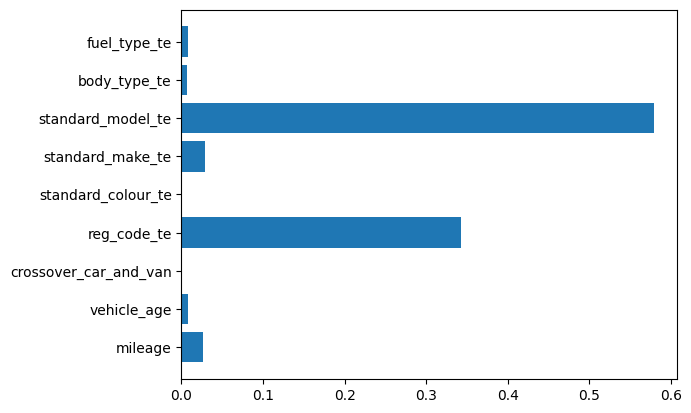

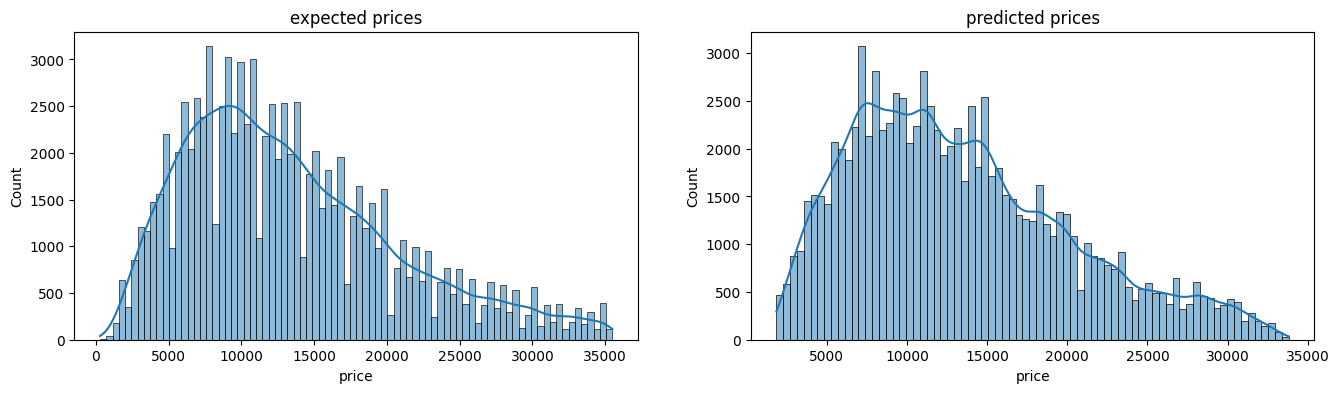

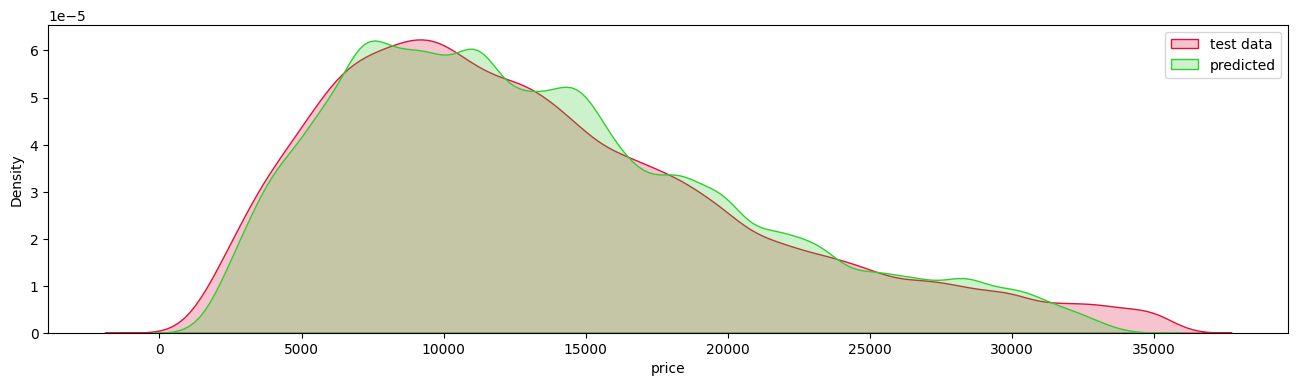

In [39]:
# SLOW (>60sec)
if run_slow_models:
    X = df.drop(columns='price')

    generate_test_split()
    generate_scaled_features()
    X_train, X_test = X_train_scaled, X_test_scaled

    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=RANDOM_STATE_SEED
    )
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    plt.barh(
        X.columns,
        rf_model.feature_importances_
    )

    log_metrics(y_pred, name="Random Forest Regressor")
    show_comparison()

The graph above suggests that the `reg_code` and `standard_model` parameters which are the most important, but of the quantitative parameters, vehicle age and mileage are the most important.

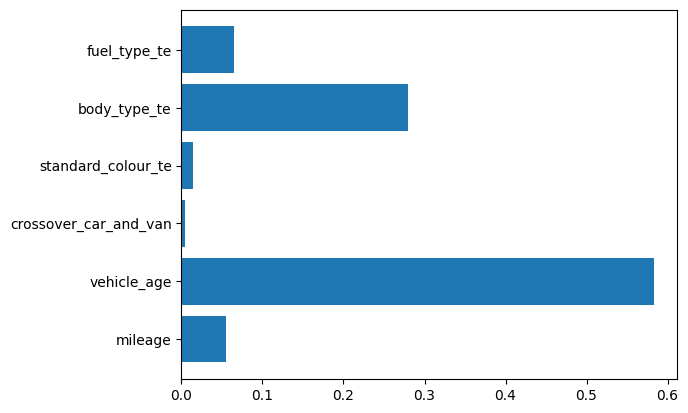

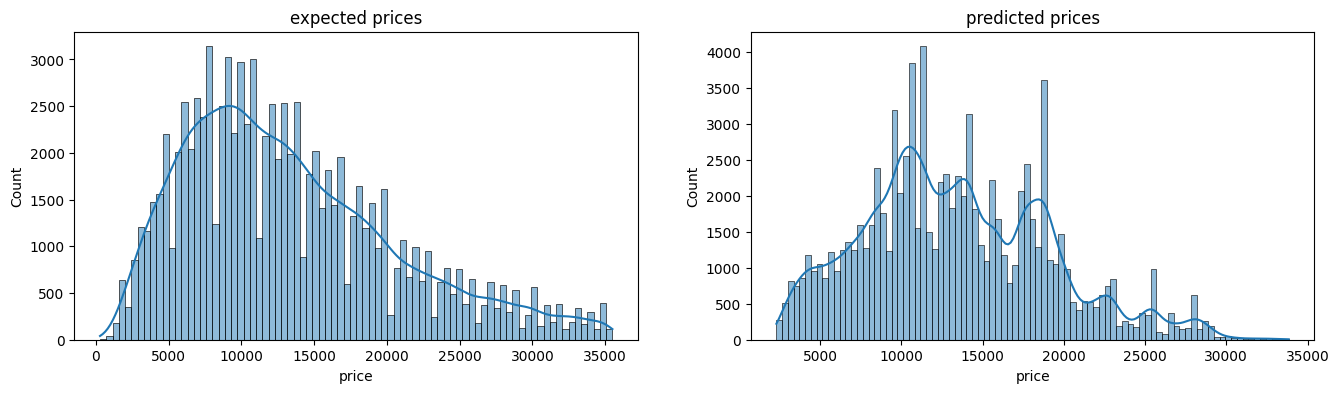

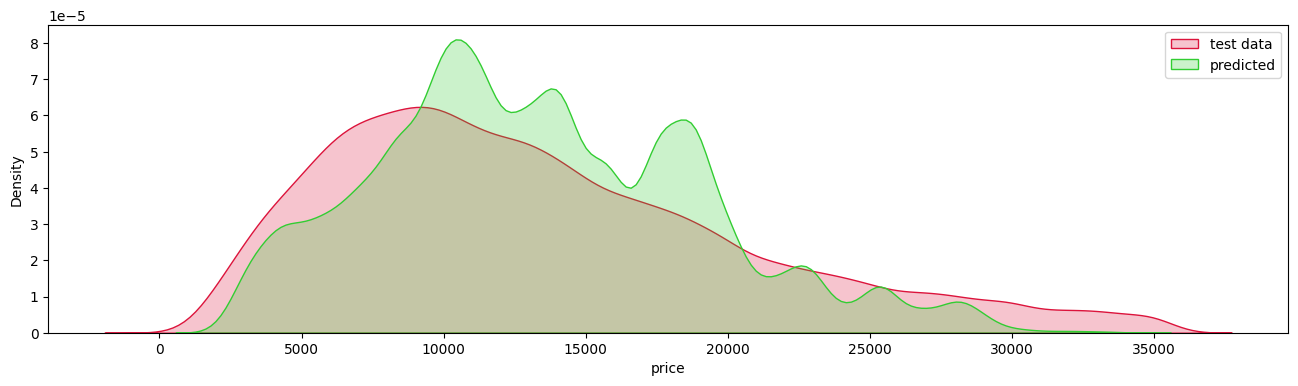

In [40]:
# SLOW (>60sec)
if run_slow_models:
    X = df.drop(columns=['price', 'reg_code_te', 'standard_model_te', 'standard_make_te'])

    generate_test_split()
    generate_scaled_features()

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=RANDOM_STATE_SEED
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    plt.barh(
        X.columns,
        model.feature_importances_
    )

    log_metrics(y_pred, name="Random Forest Regressor -reg,model")
    show_comparison()

## Model Statistics

In [41]:
# Error statistics
for model_name, model_metrics in metrics.items():
    print(model_name)
    for metric_name, metric_value in model_metrics.items():
        print(f'\t{metric_name:>4}: {metric_value:<5}')

Linear Regressor full
	  r²: 0.8204
	 mae: 2323.6399
	 mse: 9623637.9490
	rmse: 3102.1989
Linear Regressor -mileage
	  r²: 0.8000
	 mae: 2462.4140
	 mse: 10713322.1894
	rmse: 3273.1212
Linear Regressor -mileage,model,reg
	  r²: 0.6942
	 mae: 3078.1389
	 mse: 16381560.3708
	rmse: 4047.4140
Linear Regressor -mileage,reg
	  r²: 0.7782
	 mae: 2608.1061
	 mse: 11883758.4826
	rmse: 3447.2828
Linear Regressor -age,model,reg
	  r²: 0.6569
	 mae: 3275.1417
	 mse: 18380528.4652
	rmse: 4287.2519
Linear Regressor -age,reg
	  r²: 0.7651
	 mae: 2673.2707
	 mse: 12587099.4489
	rmse: 3547.8302
Linear Regressor +age,mileage
	  r²: 0.3553
	 mae: 4562.9908
	 mse: 34540278.1502
	rmse: 5877.0978
DecisionTreeRegressor(max_depth=15, min_samples_split=38, random_state=47)
	  r²: 0.9171
	 mae: 1440.5501
	 mse: 4441191.1348
	rmse: 2107.4134
Random Forest Regressor
	  r²: 0.9046
	 mae: 1588.1380
	 mse: 5109936.5949
	rmse: 2260.5169
Random Forest Regressor -reg,model
	  r²: 0.6159
	 mae: 3318.5121
	 mse: 20577862

### Cross-Validation

In [42]:
# linear regressor k-fold cross-validation
X = df.drop(columns='price')
y = df['price']

model = LinearRegression()

print(scores := cross_val_score(model, X, y, cv=5))
print(f'{100 * scores.mean():.2f}% Accuracy')

[0.82004298 0.82266413 0.82271841 0.81978069 0.82184242]
82.14% Accuracy


In [43]:
# decision tree k-fold cross-validation
X = df.drop(columns='price')
y = df['price']

model = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=38,
    random_state=RANDOM_STATE_SEED
)

print(scores := cross_val_score(model, X, y, cv=5))
print(f'{100 * scores.mean():.2f}% Accuracy')

[0.9218092  0.92116299 0.9212371  0.91927907 0.92102638]
92.09% Accuracy


In [44]:
# decision tree k-fold cross-validation
if run_slow_models:
    X = df.drop(columns='price')
    y = df['price']

    model = RandomForestRegressor(
        max_depth=15,
        min_samples_split=38,
        random_state=RANDOM_STATE_SEED
    )

    print(scores := cross_val_score(model, X, y, cv=5))
    print(f'{100 * scores.mean():.2f}% Accuracy')

[0.93131197 0.93111967 0.93126214 0.92869417 0.93016563]
93.05% Accuracy


### SHAP framework

In [45]:
import shap

X = df.drop(columns='price')
generate_test_split()
generate_scaled_features()
X_train, X_test = X_train_scaled, X_test_scaled
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

c:\Users\jakeh\dev\UA92\software\12-Applied_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


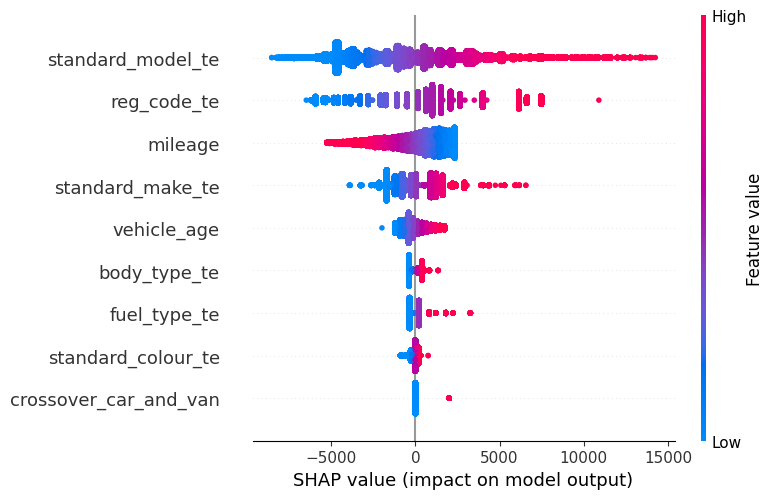

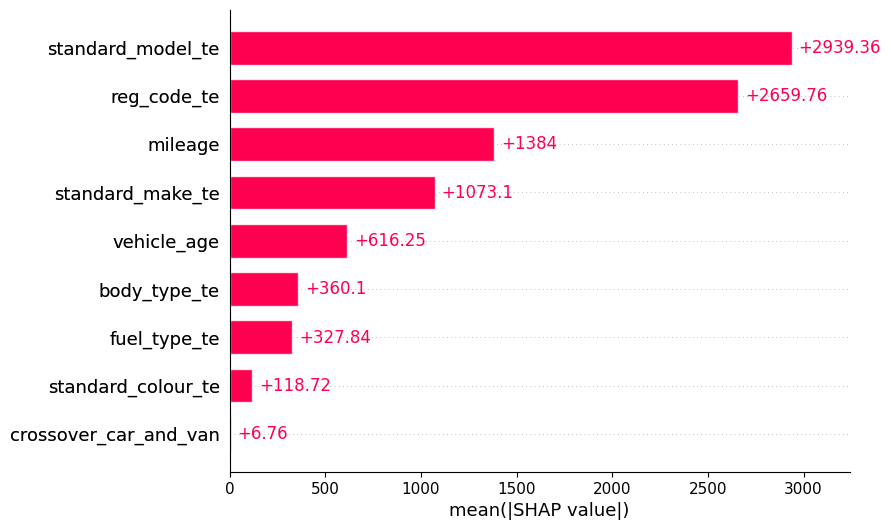

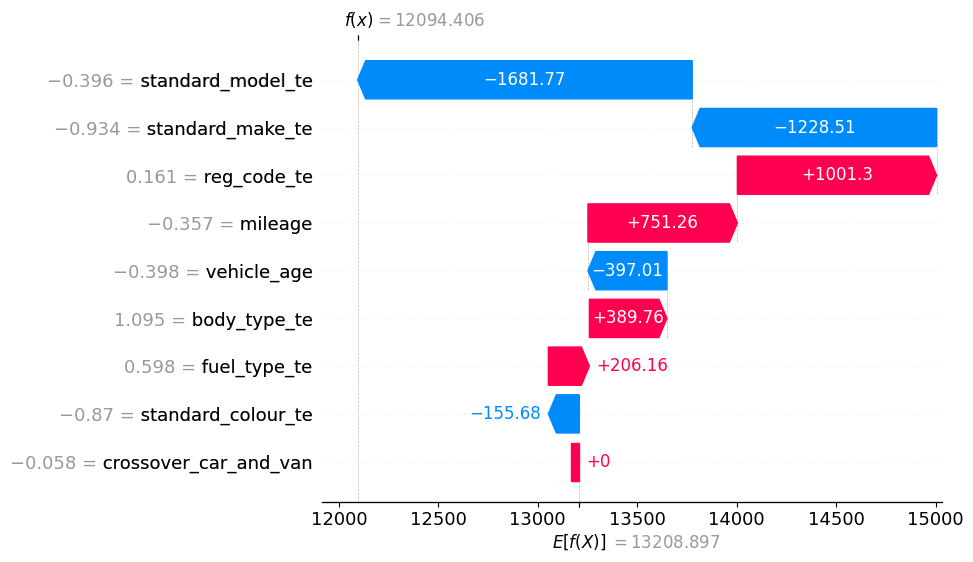

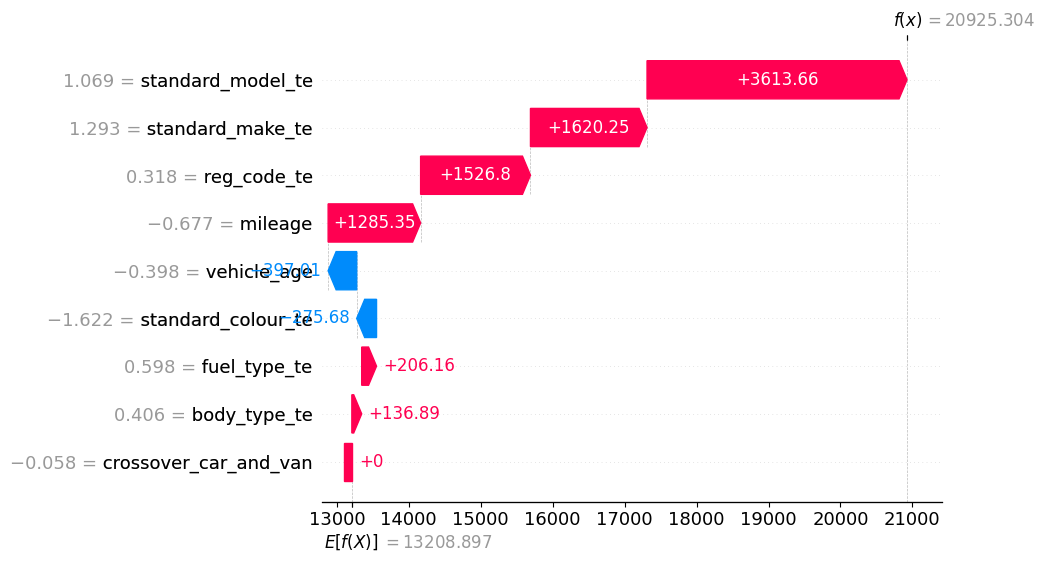

In [46]:
explainer = shap.Explainer(
    lr_model,
    X_train
)
shap_values = explainer(X_test)

if render_plots:
    shap.summary_plot(shap_values, X_test)
    shap.plots.bar(shap_values)
    shap.plots.waterfall(shap_values[2])
    shap.plots.waterfall(shap_values[4])

 97%|=================== | 90871/93474 [00:17<00:00]       

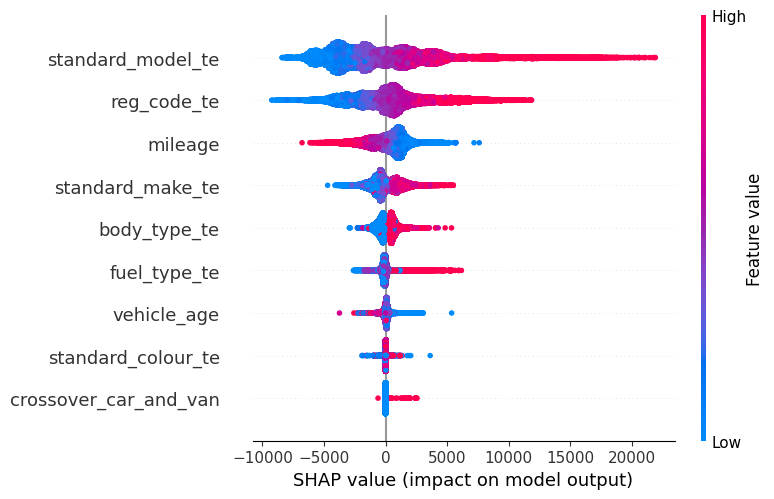

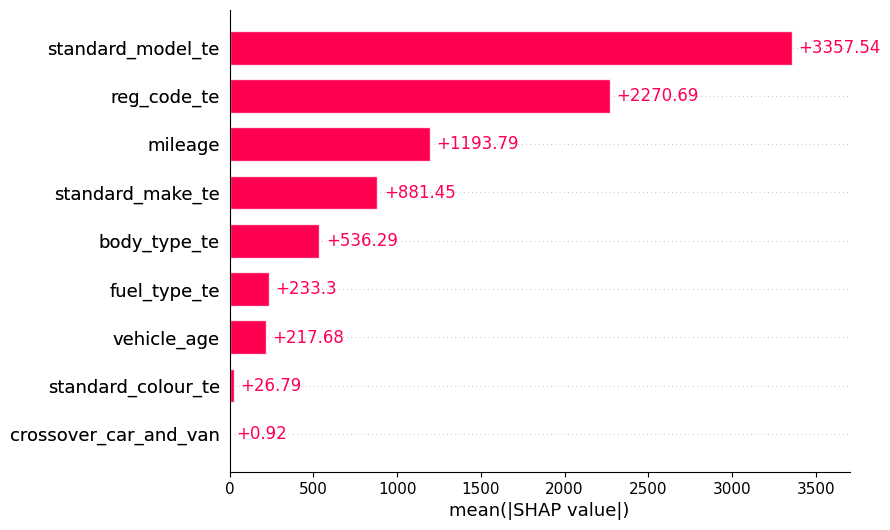

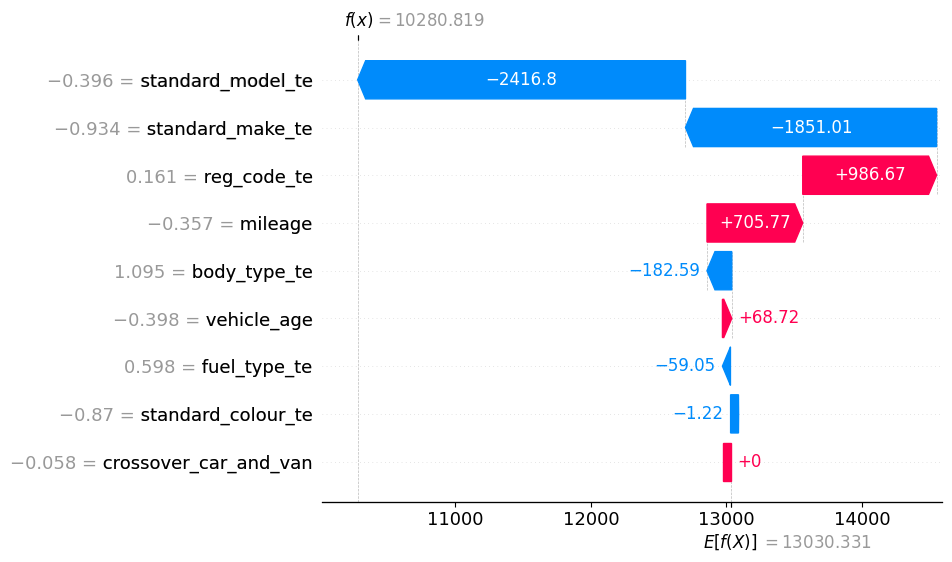

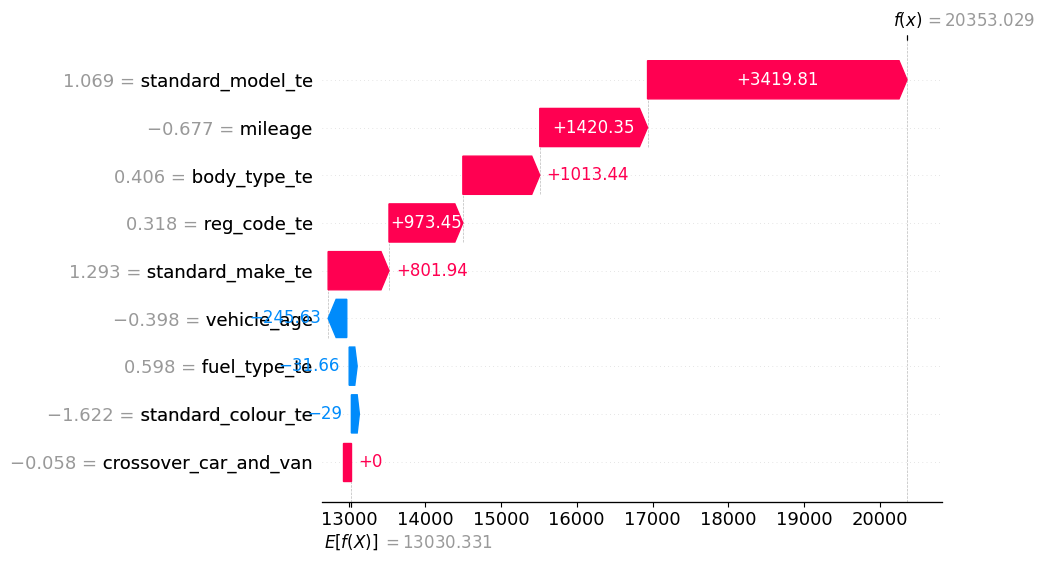

In [47]:
explainer = shap.TreeExplainer(
    dt_model,
    X_train
)
shap_values = explainer(X_test)

if render_plots:
    shap.summary_plot(shap_values, X_test)
    shap.plots.bar(shap_values)
    shap.plots.waterfall(shap_values[2])
    shap.plots.waterfall(shap_values[4])

100%|===================| 93393/93474 [11:24<00:00]        

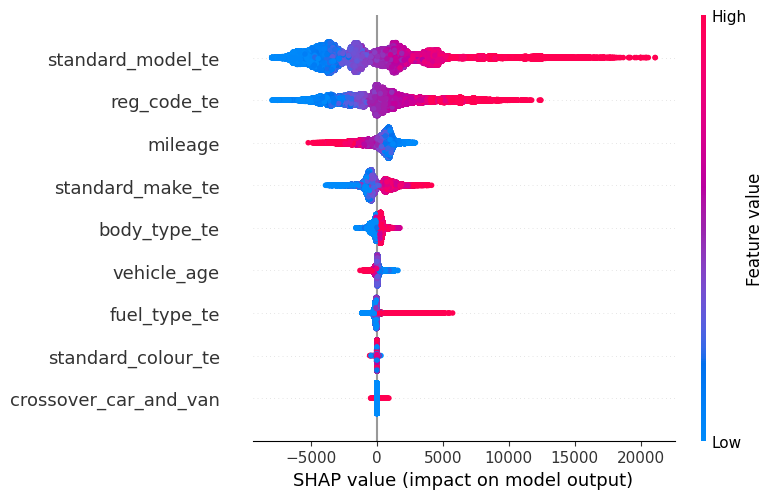

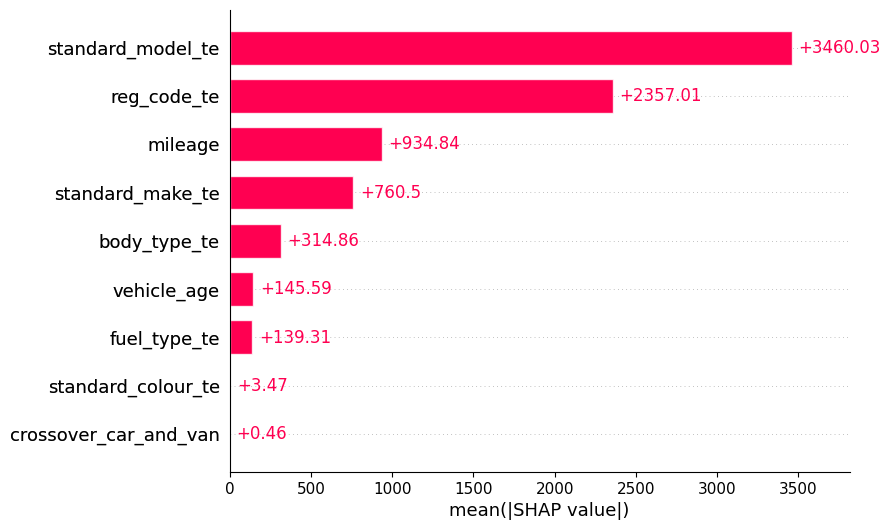

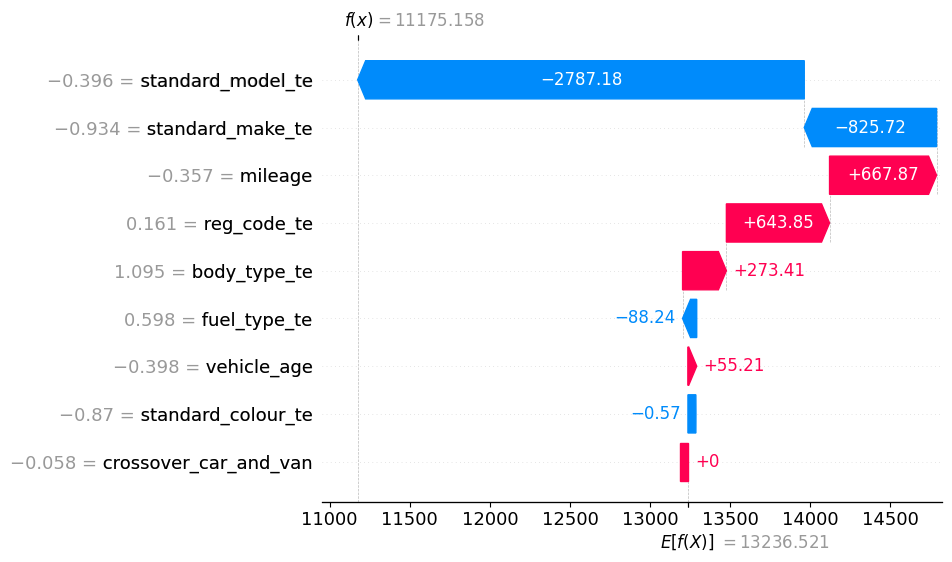

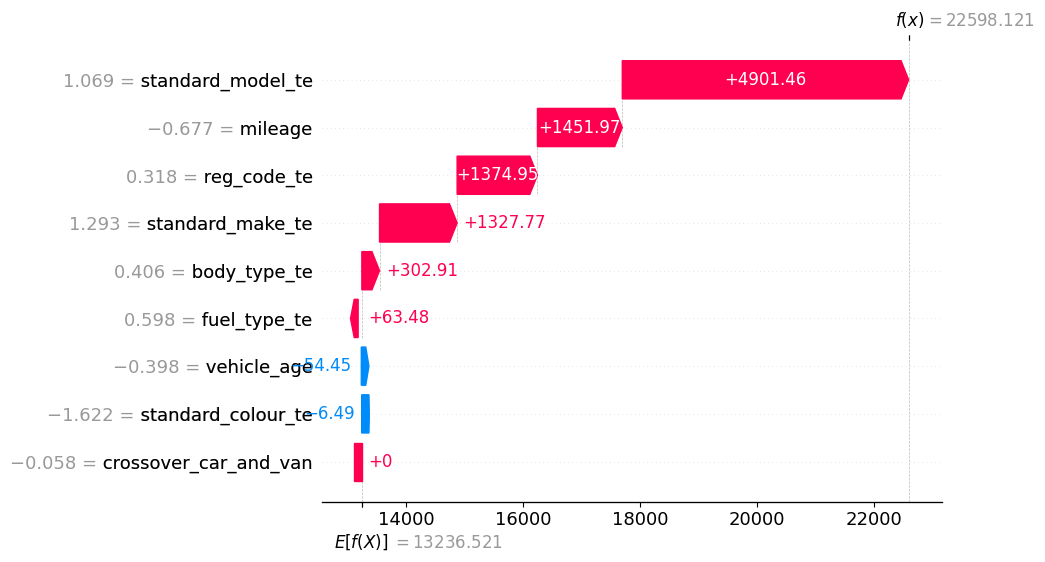

In [48]:
if run_slow_models:
    explainer = shap.TreeExplainer(
        rf_model,
        X_train
    )
    shap_values = explainer(X_test)

    if render_plots:
        shap.summary_plot(shap_values, X_test)
        shap.plots.bar(shap_values)
        shap.plots.waterfall(shap_values[2])
        shap.plots.waterfall(shap_values[4])